In [1]:
# NOTE: unfortunately depends_on_optional machinery in a submodule prevents autoreload from working for that submodule
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
from imview import pltlib
from pygeotools.lib import iolib,warplib,geolib
import geopandas as gpd
from shapely.geometry import box
import glob

In [3]:
%cd /panfs/ccds02/nobackup/people/sbhusha1/pcd/manuscript_prepration/

/panfs/ccds02/nobackup/people/sbhusha1/pcd/manuscript_prepration


In [5]:
%cd usgs/WI_Brown_2_2020_processing/

/panfs/ccds02/nobackup/people/sbhusha1/pcd/manuscript_prepration/usgs/WI_Brown_2_2020_processing


In [6]:
!mv /home/sbhusha1/notebooks/pcd/original_left_large_area.tif* ../../../manuscript_processing/WI_Brown_2_2020_processing_35cm/
!mv /home/sbhusha1/notebooks/pcd/original_right_large_area.tif* ../../../manuscript_processing/WI_Brown_2_2020_processing_35cm/

In [9]:
gdf = gpd.read_file('/home/sbhusha1/notebooks/pcd/Zoom-in-GIF_extent1.geojson').to_crs('EPSG:32616')

In [14]:
extent = gdf.total_bounds.tolist()

In [15]:
left_final_stereo_img_fn = 'stereo_WV03WV03_20200502_104001005B461800_104001005ACC6E00/filled/104001005B461800_left_ortho_0.35m_final_aligned_to_REFDEM.tif'
right_final_stereo_img_fn = 'stereo_WV03WV03_20200502_104001005B461800_104001005ACC6E00/filled/104001005ACC6E00_right_ortho_0.35m_final_aligned_to_REFDEM.tif'
lidar_reference_img_fn = '../../../manuscript_processing/WI_Brown_2_2020_processing_35cm/WI_Brown_2_2020-intensity_mos.tif'
og_left_fn = '../../../manuscript_processing/WI_Brown_2_2020_processing_35cm/original_left_large_area.tif'
og_right_fn = '../../../manuscript_processing/WI_Brown_2_2020_processing_35cm/original_right_large_area.tif'

ds_list = warplib.memwarp_multi_fn([left_final_stereo_img_fn,right_final_stereo_img_fn,og_left_fn,og_right_fn,lidar_reference_img_fn],extent=extent)
final_left,final_right,og_left,og_right,ref = [iolib.ds_getma(ds) for ds in ds_list]


Warping all inputs to the following:
Resolution: 0.35
Extent: [416901.5846528595, 4945938.541689618, 416984.78487310413, 4945998.245957253]
Projection: '+proj=utm +zone=16 +ellps=WGS84 +units=m +no_defs'
Resampling alg: cubic

1 of 5: stereo_WV03WV03_20200502_104001005B461800_104001005ACC6E00/filled/104001005B461800_left_ortho_0.35m_final_aligned_to_REFDEM.tif
nl: 171 ns: 238 res: 0.350
100 - done.
0...10...20...30...40...50...60...70...80...90...2 of 5: stereo_WV03WV03_20200502_104001005B461800_104001005ACC6E00/filled/104001005ACC6E00_right_ortho_0.35m_final_aligned_to_REFDEM.tif
nl: 171 ns: 238 res: 0.350
100 - done.
0...10...20...30...40...50...60...70...80...90...3 of 5: ../../../manuscript_processing/WI_Brown_2_2020_processing_35cm/original_left_large_area.tif
nl: 171 ns: 238 res: 0.350
100 - done.
0...10...20...30...40...50...60...70...80...90...4 of 5: ../../../manuscript_processing/WI_Brown_2_2020_processing_35cm/original_right_large_area.tif
nl: 171 ns: 238 res: 0.350
100 - d

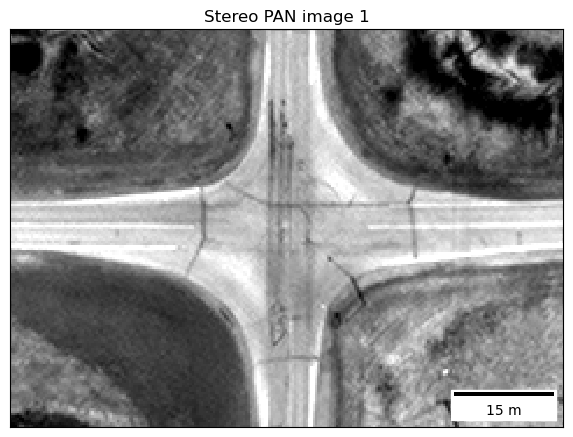

In [26]:
f,ax = plt.subplots(figsize=(6,8))
pltlib.iv(final_left,cmap='gray',ax=ax,cbar=False,title='Stereo PAN image 1')
pltlib.add_scalebar(ax=ax,res=0.35)
f.savefig('/home/sbhusha1/notebooks/pcd/final_left_zoomin.png',dpi=300)

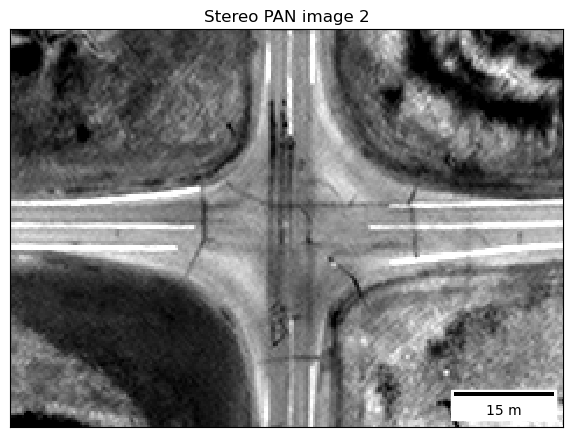

In [27]:
f,ax = plt.subplots(figsize=(6,8))
pltlib.iv(final_right,cmap='gray',ax=ax,cbar=False,title='Stereo PAN image 2')
pltlib.add_scalebar(ax=ax,res=0.35)
f.savefig('/home/sbhusha1/notebooks/pcd/final_right_zoomin.png',dpi=300)

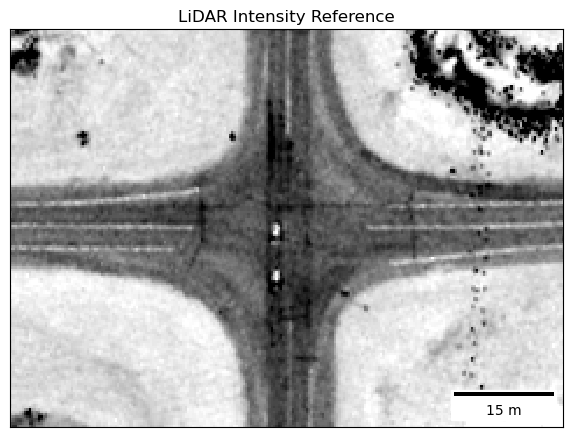

In [28]:
f,ax = plt.subplots(figsize=(6,8))
pltlib.iv(ref,cmap='gray',ax=ax,cbar=False,title='LiDAR Intensity Reference')
pltlib.add_scalebar(ax=ax,res=0.35)
f.savefig('/home/sbhusha1/notebooks/pcd/ref.png',dpi=300)

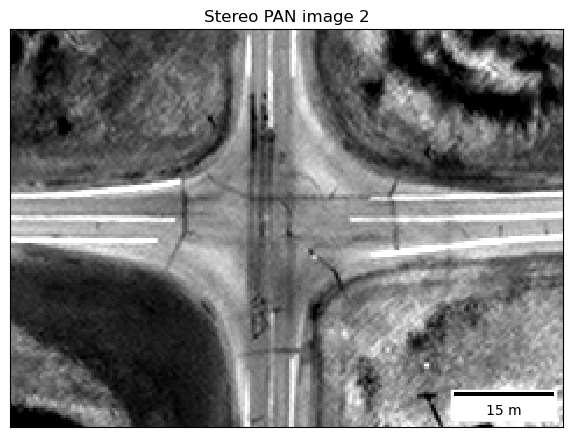

In [29]:
f,ax = plt.subplots(figsize=(6,8))
pltlib.iv(og_right,cmap='gray',ax=ax,cbar=False,title='Stereo PAN image 2')
pltlib.add_scalebar(ax=ax,res=0.35)
f.savefig('/home/sbhusha1/notebooks/pcd/og_right_zoomin.png',dpi=300)

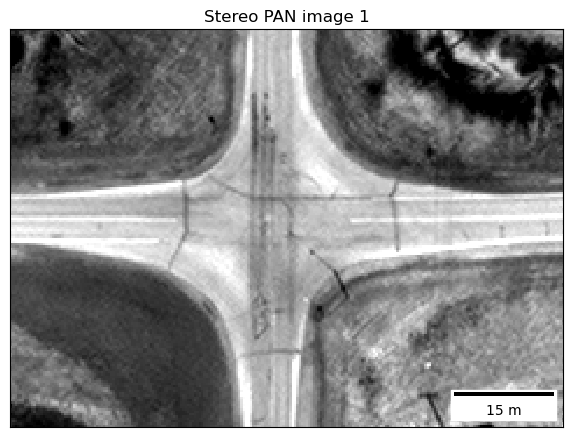

In [30]:
f,ax = plt.subplots(figsize=(6,8))
pltlib.iv(og_left,cmap='gray',ax=ax,cbar=False,title='Stereo PAN image 1')
pltlib.add_scalebar(ax=ax,res=0.35)
f.savefig('/home/sbhusha1/notebooks/pcd/og_left_zoomin.png',dpi=300)

In [ ]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import rasterio

def raster_to_gif(
    raster_ma_list,
    out_gif="output.gif",
    band=1,
    cmap="gray",
    fps=2,
    dpi=150,
    figsize=(10, 8),
    clim=None,
    title_list=None,
    colorbar=True,
    nodata_transparent=True,
):
    """
    Create an animated GIF from a list of raster files.

    Parameters
    ----------
    raster_list : list of str
        Paths to raster files (GeoTIFF, etc.).
    out_gif : str
        Output GIF filename.
    band : int
        Band number to read (1-indexed).
    cmap : str
        Matplotlib colormap name.
    fps : int
        Frames per second.
    dpi : int
        Output resolution.
    figsize : tuple
        Figure size in inches.
    clim : tuple or None
        (vmin, vmax) for consistent color scaling. If None, computed from all frames.
    title_list : list of str or None
        Title for each frame.
    colorbar : bool
        Whether to add a colorbar.
    nodata_transparent : bool
        Mask nodata values as transparent.
    """

    # --- Read all arrays and compute global clim if needed ---
    arrays = []
    #extents = []
    for raster in raster_list:
    #     with rasterio.open(fn) as src:
    #         arr = src.read(band).astype(float)
    #         ndv = src.nodata
    #         if nodata_transparent and ndv is not None:
    #             arr[arr == ndv] = np.nan
    #         arrays.append(arr)
    #         # Geographic extent for proper axis labeling
    #         t = src.transform
    #         extent = [
    #             t.c,
    #             t.c + t.a * src.width,
    #             t.f + t.e * src.height,
    #             t.f,
    #         ]
    #         extents.append(extent)

    # if clim is None:
    #     vmin = np.nanmin([np.nanmin(a) for a in arrays])
    #     vmax = np.nanmax([np.nanmax(a) for a in arrays])
    # else:
    #     vmin, vmax = clim

    # --- Set up figure ---
    fig, ax = plt.subplots()
    im = pltlib.iv(
        raster,
        cmap=cmap,
        cbar=False)

    if title_list:
        ax.set_title(title_list[0], fontsize=14)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

    # --- Update function for animation ---
    def update(frame_idx):
        im.set_data(a[frame_idx])
        im.set_extent(extents[frame_idx])
        if title_list:
            ax.set_title(title_list[frame_idx], fontsize=14)
        return [im]

    anim = FuncAnimation(
        fig,
        update,
        frames=len(arrays),
        interval=1000 / fps,
        blit=True,
    )

    # --- Save ---
    writer = PillowWriter(fps=fps)
    anim.save(out_gif, writer=writer, dpi=dpi)
    plt.close(fig)
    print(f"GIF saved to: {out_gif}")


# =============================================================
# Example usage
# =============================================================
if __name__ == "__main__":
    # Collect raster files (sorted)
    raster_files = sorted(glob.glob("path/to/rasters/*.tif"))

    # Optional: generate titles from filenames
    import os
    titles = [os.path.basename(f).replace(".tif", "") for f in raster_files]

    raster_to_gif(
        raster_list=raster_files,
        out_gif="animation.gif",
        band=1,
        cmap="RdYlBu",
        fps=3,
        dpi=150,
        figsize=(10, 8),
        clim=None,          # auto-scale, or pass (vmin, vmax)
        title_list=titles,
        colorbar=True,
    )

In [ ]:
for img in [final_left,final_right,ref]:
    fig, ax = plt.subplots()
        im = ax.imshow(
            img,
            cmap='gray',
           cbar=False)
        
        if title_list:
            ax.set_title(title_list[0], fontsize=14)
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
    
        # --- Update function for animation ---
        def update(frame_idx):
            im.set_data(arrays[frame_idx])
            im.set_extent(extents[frame_idx])
            if title_list:
                ax.set_title(title_list[frame_idx], fontsize=14)
            return [im]
    
        anim = FuncAnimation(
            fig,
            update,
            frames=len(arrays),
            interval=1000 / fps,
            blit=True,
        )